In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
import xgboost as xgb

DATA_PATH = '../data'

# Load saved dataset
full_dataset = pd.read_parquet(f'{DATA_PATH}/full_dataset.parquet')

print(full_dataset.shape)
print(full_dataset.head())

(50000190, 34)
   userId  movieId  watched  user_rating_count  user_avg_rating  \
0       1      296        1                 70         3.814286   
1       1      306        1                 70         3.814286   
2       1      307        1                 70         3.814286   
3       1      665        1                 70         3.814286   
4       1      899        1                 70         3.814286   

   user_rating_std  user_peak_hour  user_peak_day user_peak_season  \
0         1.004235              12              2           spring   
1         1.004235              12              2           spring   
2         1.004235              12              2           spring   
3         1.004235              12              2           spring   
4         1.004235              12              2           spring   

   movie_rating_count  ...  Film-Noir  Horror  IMAX Musical  Mystery  Romance  \
0               79672  ...          0       0     0       0        0        0   

In [2]:
# Define features and target
# Drop columns that aren't features
drop_cols = ['userId', 'movieId', 'watched', 'user_peak_season', 'movie_peak_season']

X = full_dataset.drop(columns=drop_cols)
y = full_dataset['watched']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

Features shape: (50000190, 29)
Target shape: (50000190,)

Feature columns:
['user_rating_count', 'user_avg_rating', 'user_rating_std', 'user_peak_hour', 'user_peak_day', 'movie_rating_count', 'movie_avg_rating', 'movie_rating_std', 'movie_peak_hour', '(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


In [3]:
# Split data — 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keeps 50/50 balance in both splits
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("\nTrain target distribution:")
print(y_train.value_counts())

Train size: (40000152, 29)
Test size: (10000038, 29)

Train target distribution:
watched
1    20000076
0    20000076
Name: count, dtype: int64


In [4]:
# Check where NaNs are
print("NaN counts per column:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

NaN counts per column:
movie_rating_std    3505554
dtype: int64


In [5]:
# Fill NaN standard deviations with 0
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

print("NaNs remaining:", X_train.isnull().sum().sum())

NaNs remaining: 0


In [6]:
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='auc',
    tree_method='hist',
    n_jobs=-1,
    verbosity=1
)
xgb_model.fit(X_train, y_train)

xgb_preds = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_preds)
print(f"XGBoost AUC-ROC: {xgb_auc:.4f}")

Training XGBoost...
XGBoost AUC-ROC: 0.9878


               feature  importance
5   movie_rating_count    0.858975
0    user_rating_count    0.098532
20              Horror    0.003670
8      movie_peak_hour    0.003587
10              Action    0.003489
26            Thriller    0.003329
7     movie_rating_std    0.002615
3       user_peak_hour    0.002382
1      user_avg_rating    0.002328
24             Romance    0.002297


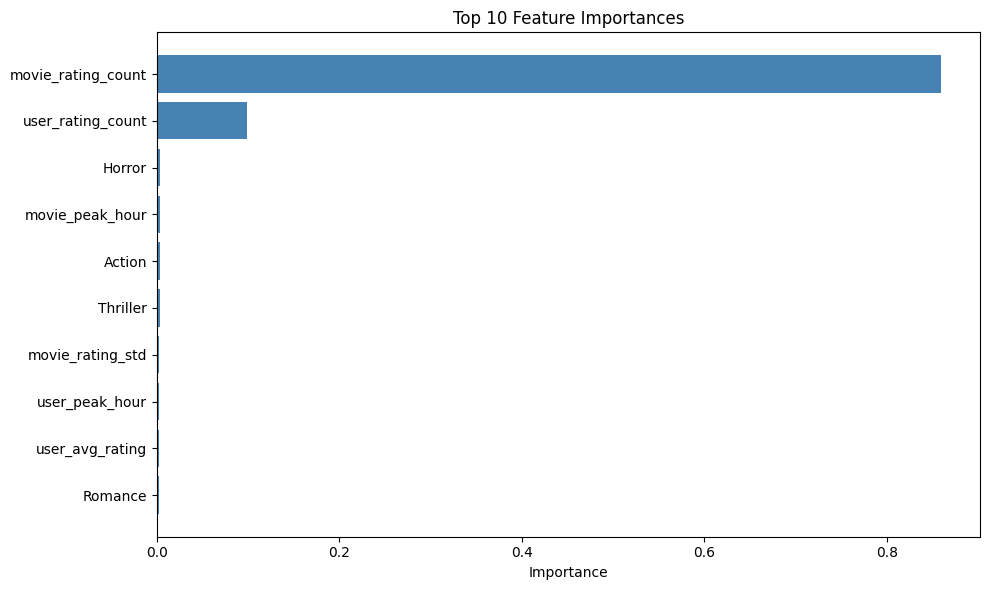

In [7]:
import matplotlib.pyplot as plt

# Feature importance
importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance.head(10))

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance['feature'][:10][::-1], importance['importance'][:10][::-1], color='steelblue')
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [8]:
# Remove popularity dominance
drop_cols_v2 = ['userId', 'movieId', 'watched', 'user_peak_season', 
                'movie_peak_season', 'movie_rating_count', 'user_rating_count']

X_v2 = full_dataset.drop(columns=drop_cols_v2)
y_v2 = full_dataset['watched']

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=42, stratify=y_v2
)

X_train_v2 = X_train_v2.fillna(0)
X_test_v2 = X_test_v2.fillna(0)

print("New feature set:")
print(X_train_v2.columns.tolist())

New feature set:
['user_avg_rating', 'user_rating_std', 'user_peak_hour', 'user_peak_day', 'movie_avg_rating', 'movie_rating_std', 'movie_peak_hour', '(no genres listed)', 'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


In [9]:
print("Training XGBoost v2 (no popularity bias)...")
xgb_model_v2 = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='auc',
    tree_method='hist',
    n_jobs=-1,
    verbosity=1
)
xgb_model_v2.fit(X_train_v2, y_train_v2)

xgb_preds_v2 = xgb_model_v2.predict_proba(X_test_v2)[:, 1]
xgb_auc_v2 = roc_auc_score(y_test_v2, xgb_preds_v2)
print(f"XGBoost v2 AUC-ROC: {xgb_auc_v2:.4f}")

Training XGBoost v2 (no popularity bias)...
XGBoost v2 AUC-ROC: 0.9497


               feature  importance
6      movie_peak_hour    0.274859
5     movie_rating_std    0.129281
8               Action    0.071437
9            Adventure    0.068421
7   (no genres listed)    0.063802
14         Documentary    0.056575
23              Sci-Fi    0.042494
12              Comedy    0.040791
24            Thriller    0.028146
4     movie_avg_rating    0.027552


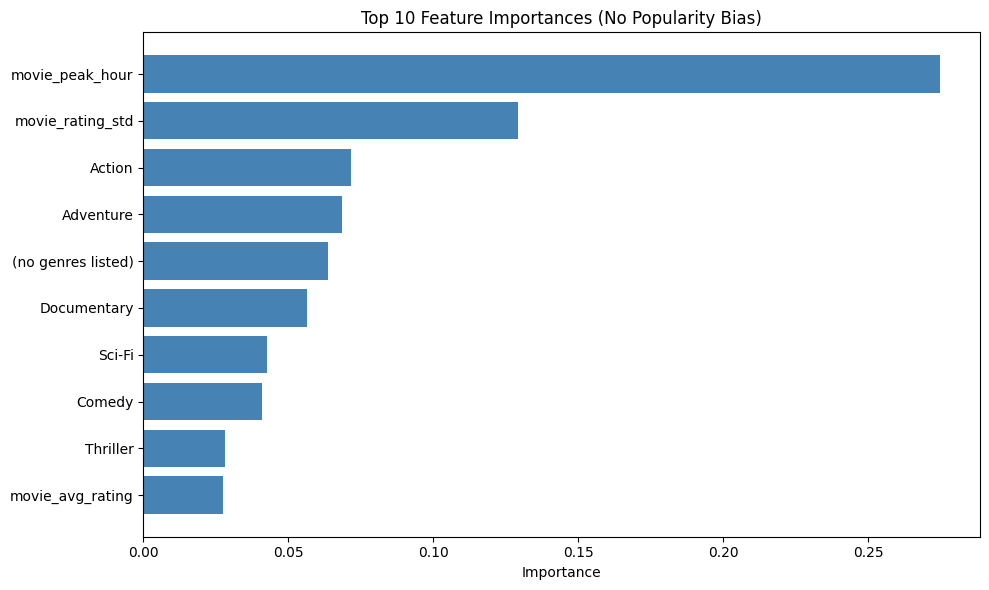

In [10]:
importance_v2 = pd.DataFrame({
    'feature': X_train_v2.columns,
    'importance': xgb_model_v2.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_v2.head(10))

plt.figure(figsize=(10, 6))
plt.barh(importance_v2['feature'][:10][::-1], importance_v2['importance'][:10][::-1], color='steelblue')
plt.title('Top 10 Feature Importances (No Popularity Bias)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [11]:
import pickle

with open('../data/xgb_model_v1.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

with open('../data/xgb_model_v2.pkl', 'wb') as f:
    pickle.dump(xgb_model_v2, f)

print("Models saved!")

Models saved!
